# **HW1**
Group 2:
Garrett Collier
Xiaoxia Zhang
Akuearias Liu

#### Import packages & data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [ ]:
dataset = pd.read_csv('happiness_data.csv')
dataset

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
...,...,...,...,...,...,...,...,...,...,...,...
1944,Zimbabwe,2016,3.735,7.984,0.768,54.40,0.733,-0.095,0.724,0.738,0.209
1945,Zimbabwe,2017,3.638,8.016,0.754,55.00,0.753,-0.098,0.751,0.806,0.224
1946,Zimbabwe,2018,3.616,8.049,0.775,55.60,0.763,-0.068,0.844,0.710,0.212
1947,Zimbabwe,2019,2.694,7.950,0.759,56.20,0.632,-0.064,0.831,0.716,0.235


## **A. Summarization - 5pts**
Summarize the data. How much data is present? What attributes/features are continuous valued? Which attributes are categorical? [5 points]\
1) How much data is present? - 1 pt\
*There are 1949 rows and 11 columns' data presented.*\
2) What attributes/features are continuous valued? - 2 pt\
*year, Life Ladder, Log GDP per capita, Social support, Healthy life expectancy at birth, Freedom to make life choices, Generosity, Perceptions of corruption, Positive affect, Negative affect*\
3) Which attributes are categorical? - 2 pt\
*Country name*


In [ ]:
# 1) How much data is present? - 1 pt
print("Data Shape:\n", dataset.shape)

# datatype
print("\nData Types\n:", dataset.dtypes)
# 2) What attributes/features are continuous valued? - 2 pt
continuous_features = dataset.select_dtypes(include=np.number).columns.tolist()
print(f"\nContinuous features: {continuous_features}")

# 3) Which attributes are categorical? - 2 pt
categorical_features = dataset.select_dtypes(exclude=np.number).columns.tolist()
print(f"Categorical features: {categorical_features}")

Data Shape:
 (1949, 11)

Data Types
: Country name                         object
year                                  int64
Life Ladder                         float64
Log GDP per capita                  float64
Social support                      float64
Healthy life expectancy at birth    float64
Freedom to make life choices        float64
Generosity                          float64
Perceptions of corruption           float64
Positive affect                     float64
Negative affect                     float64
dtype: object

Continuous features: ['year', 'Life Ladder', 'Log GDP per capita', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect']
Categorical features: ['Country name']


## **B. Visualization and summary Statistics - 5pts**
Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Explain noticeable traits for key attributes. Are there any attributes that might require special treatment? If so, what special treatment might they require? [5 points]\
1) Visualization and summary Statistics -3 pts\
*The distributions of continuous features are presented by using histograms and kernel density estimates.  Categorical features are examined using countplots.*\
2) Special Treatment Needed - 2 pts\
*Dropped irrelevant attributs "year" and "life ladder", transformed categorical data "country name". Speicifically, 'Country name' feature was handled by using one-hot encoding followed by dimensionality reduction with Truncated SVD, addresseing the high cardinality of the country names, and preventing issues with some modeling techniques and reducing the feature space.*


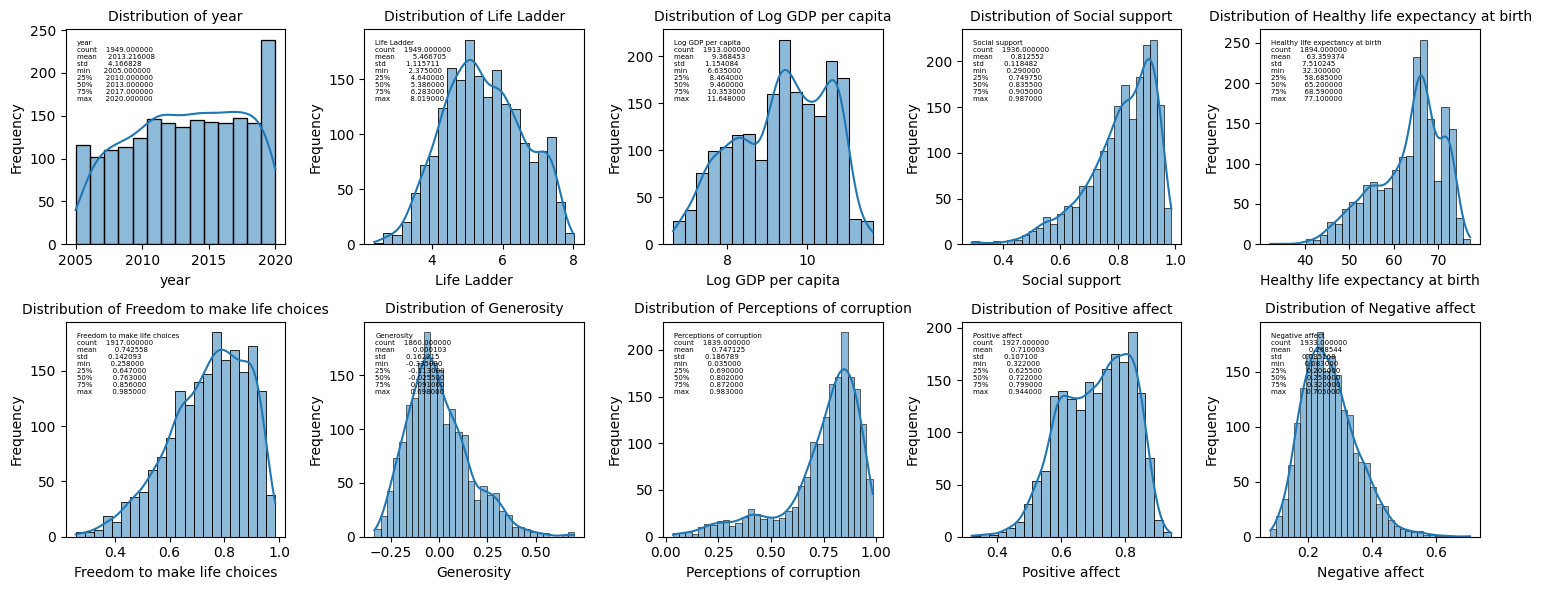

Country name
Zimbabwe        15
South Africa    15
Tanzania        15
Denmark         15
Tajikistan      15
                ..
Maldives         1
Suriname         1
Cuba             1
Oman             1
Guyana           1
Name: count, Length: 166, dtype: int64


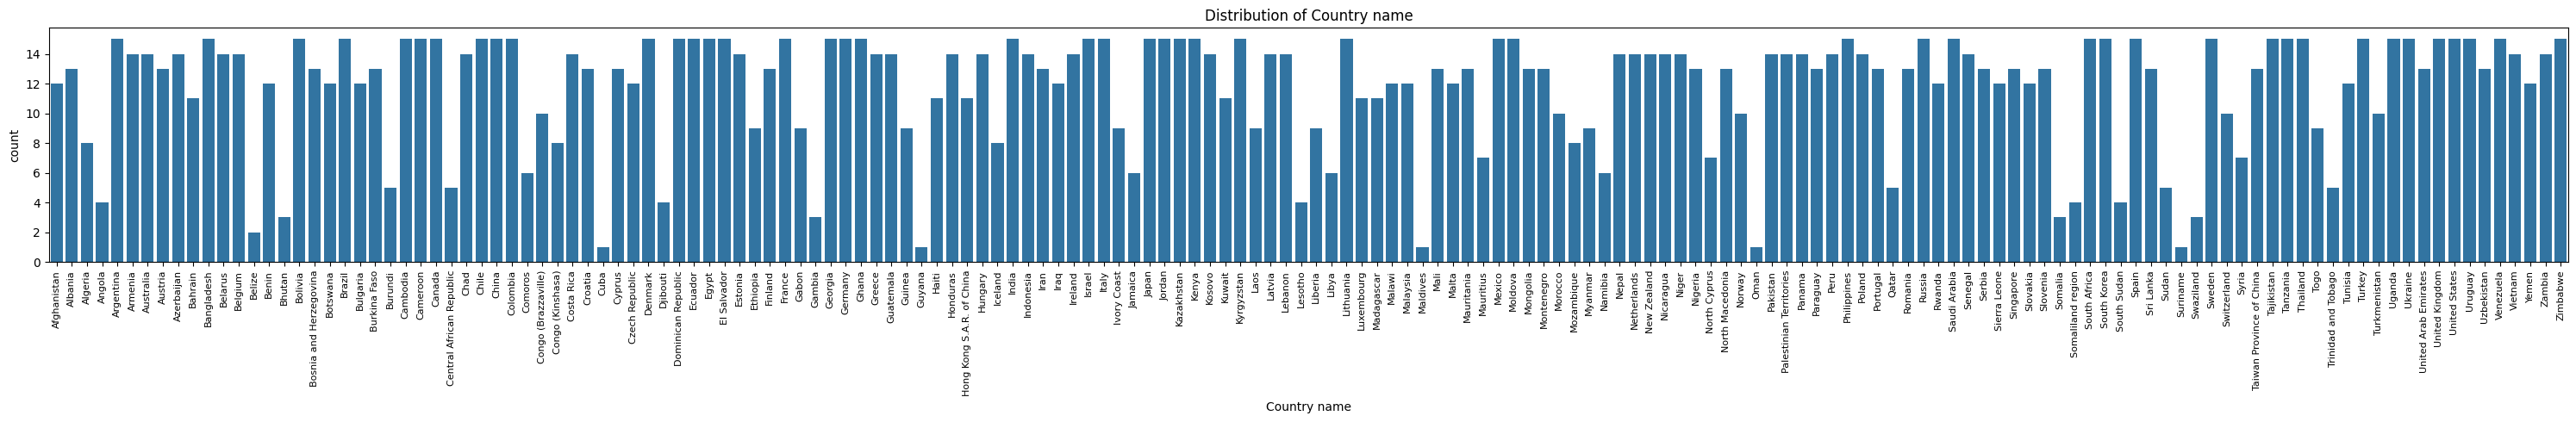

In [ ]:
# 1) Visualization and summary Statistics -3 pts
# print("\nSummary Statistics:\nOverall summary\n", dataset.describe(include='all'))
# Instaed of printing statistical value for each attribute and plot the distribution,
# the answer make the statistical value showing on the left top of the graph, except
# the "Country nmae" due to its quantity of unique value as the data type is categorical.
def display_stats_and_viz_conti(data, var_type, var_list):
    num_cols = 5
    num_rows = (len(var_list) + num_cols - 1) // num_cols  # Calculate rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easier iteration

    for i, var in enumerate(var_list):
        ax = axes[i]  # Get the current subplot
        # Statistics
        stats = data[var].describe()
        stats_text = var + "\n" + stats.to_string()
        ax.text(0.05, 0.95, stats_text, fontsize=5, va='top', ha='left', transform=ax.transAxes)

        # Visualization
        sns.histplot(data[var], kde=True, ax=ax)
        ax.set_title(f'Distribution of {var}', fontsize=10)
        ax.set_xlabel(var)
        ax.set_ylabel('Frequency')

        # Adjust layout and remove empty subplots
        if i >= len(var_list):
            fig.delaxes(ax) # Hide unused subplot

    fig.tight_layout()
    plt.show()
display_stats_and_viz_conti(dataset, "Continuous", continuous_features)

def display_stats_and_viz_cate(data, var_type, var_list):
  for var in var_list:
  # Categorical
  # Statistics
    value_counts = data[var].value_counts()
    print(value_counts)
  # Visualization
    plt.figure(figsize=(30,5))
    sns.countplot(x=var, data=dataset)
    plt.title(f'Distribution of {var}', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()
display_stats_and_viz_cate(dataset, "Categorical", categorical_features)

In [ ]:
# 2) Special Treatment Needed - 2 pts
# According to the requirements, we should remove "year", and "life ladder"
# and because the country name is nominal data, we should also transfer the date
# and to avoid the missing value, dropna() will be needed.
# Fix: Moved Country name encoding to its designated section (cell 10)
#dataset = dataset.drop(columns=["year", "Life Ladder"]) if "year" in dataset.columns else dataset
#dataset = dataset.dropna()

# Encoding Country Name into a Matrix
if "Country name" in dataset.columns:  # Check if 'Country name' still exists before encoding
    ## One-hot encode country names
    encoder = OneHotEncoder(sparse_output=False, drop="first")
    X_country = encoder.fit_transform(dataset[["Country name"]])

    ## Apply Truncated SVD to reduce dimensionality
    svd = TruncatedSVD(n_components=5)  # Reduce to 5 dimensions
    X_country_reduced = svd.fit_transform(X_country)

    ## Convert to DataFrame and merge
    dataset_country_reduced = pd.DataFrame(X_country_reduced, columns=[f"Country_{i}" for i in range(1, 6)])
    dataset = dataset.drop(columns=["Country name"])
    dataset = pd.concat([dataset, dataset_country_reduced], axis=1)

# Remove year and Life Ladder if they exist
dataset = dataset.drop(columns=["year", "Life Ladder"]) if "year" in dataset.columns else dataset
dataset = dataset.dropna()

In [ ]:
dataset = dataset.drop(columns=["year", "Life Ladder"]) if "year" in dataset.columns else dataset
dataset = dataset.dropna()

## **C. Correlation - 5pts**
Analyze the relationships between the data attributes, and between the data attributes and label. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [5 points]\


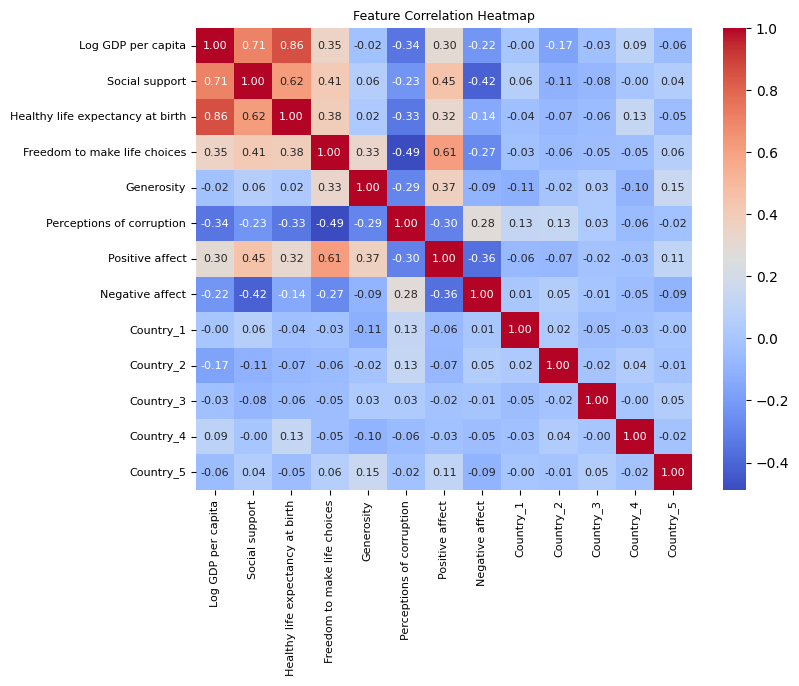

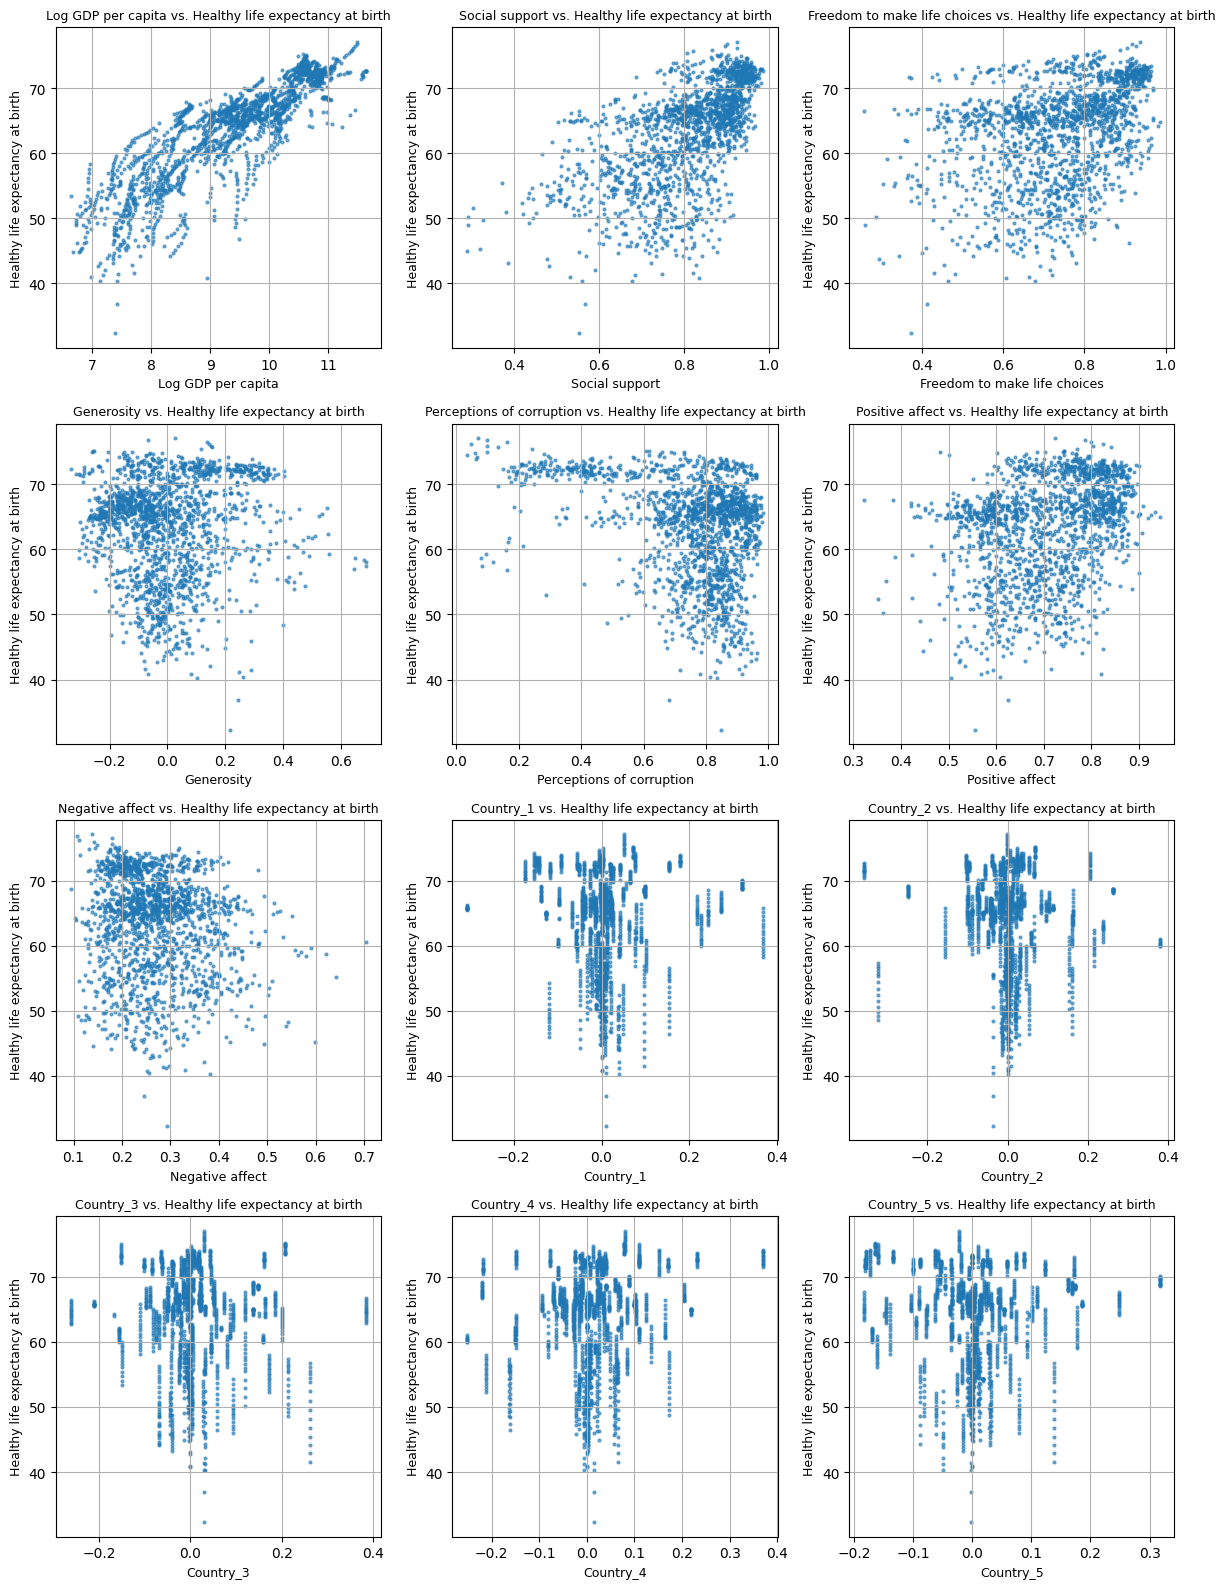

In [ ]:
# 1) PCC table has been computed -1 pt
corr_matrix = dataset.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

# 2) Scatter Plots -2 pts
attributes_scatter = ['Log GDP per capita', 'Social support',
                      'Freedom to make life choices', 'Generosity',
                      'Perceptions of corruption',
                      'Positive affect', 'Negative affect',
                      'Country_1','Country_2','Country_3','Country_4','Country_5']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 16))
for i, attribute in enumerate(attributes_scatter):
    row, col = divmod(i, 3)  # Compute subplot grid positions
    ax = axes[row, col]
    ax.scatter(dataset[attribute], dataset['Healthy life expectancy at birth'], alpha=0.6, s=4)
    ax.set_xlabel(attribute, fontsize=9)
    ax.set_ylabel('Healthy life expectancy at birth', fontsize=9)
    ax.set_title(f'{attribute} vs. Healthy life expectancy at birth', fontsize=9)
    ax.grid(True)
plt.tight_layout()
plt.show()

1) PCC table has been computed -1 pt\
We calculated the Pearson Correlation Coefficients (PCC) and displayed the matrix in the heatmap above to see correlations between those attributes.

2) Scatter Plots -2 pts\
We also used scatter plots to further illustrate relationships between selected features and the target variable 'Healthy life expectancy at birth'.

3) Discussion - 2 pts\
From the heat map and the scatter plots, we summarize as follows:

I. Log GDP per capita and Healthy life expectancy at birth, social support and log GDP per capita, freedom to make life choices and positive affect are strong positive correlations.

II. Freedom to make life choices and perceptions of corruption, social support and negative affect, log GDP per captia and perceptions of corruption are strong negative correlations.

III. According to the scatter plots, economic prosperity and health, psychological and social influences, corruption and negative effect are three most relevant attributes.


## **D. Splitting - Test/Train - 5pts**
Select 20% of the data for testing. Describe how you did that and verify that your test portion of the data is representative of the entire dataset. [5 points]

The following chunk uses train_test_split in scikit-learn to randomly divide the whole dataset into training and testing sets.

In [ ]:
# Correctly splitting into test/train -2 pts
X = dataset.drop(columns=["Healthy life expectancy at birth"]) if "Healthy life expectancy at birth" in dataset.columns else dataset
y = dataset["Healthy life expectancy at birth"]
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = imputer.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

Xtrain = X_train.copy()
Xtest = X_test.copy()
ytrain = y_train.copy()
ytest = y_test.copy()

The chunk below verifies the representativeness of the test data.

Original dataset shape: (1708, 13)
Training set shape: (1366, 12)
Testing set shape: (342, 12)

Original dataset statistics:
        Log GDP per capita  Social support  Freedom to make life choices  \
count         1708.000000     1708.000000                   1708.000000   
mean             9.321709        0.810321                      0.739442   
std              1.158344        0.121638                      0.142846   
min              6.635000        0.290000                      0.258000   
25%              8.394000        0.741000                      0.644000   
50%              9.456500        0.835000                      0.757500   
75%             10.272000        0.908000                      0.852000   
max             11.648000        0.987000                      0.985000   

        Generosity  Perceptions of corruption  Positive affect  \
count  1708.000000                1708.000000       1708.00000   
mean     -0.000638                   0.750996          0.70955   


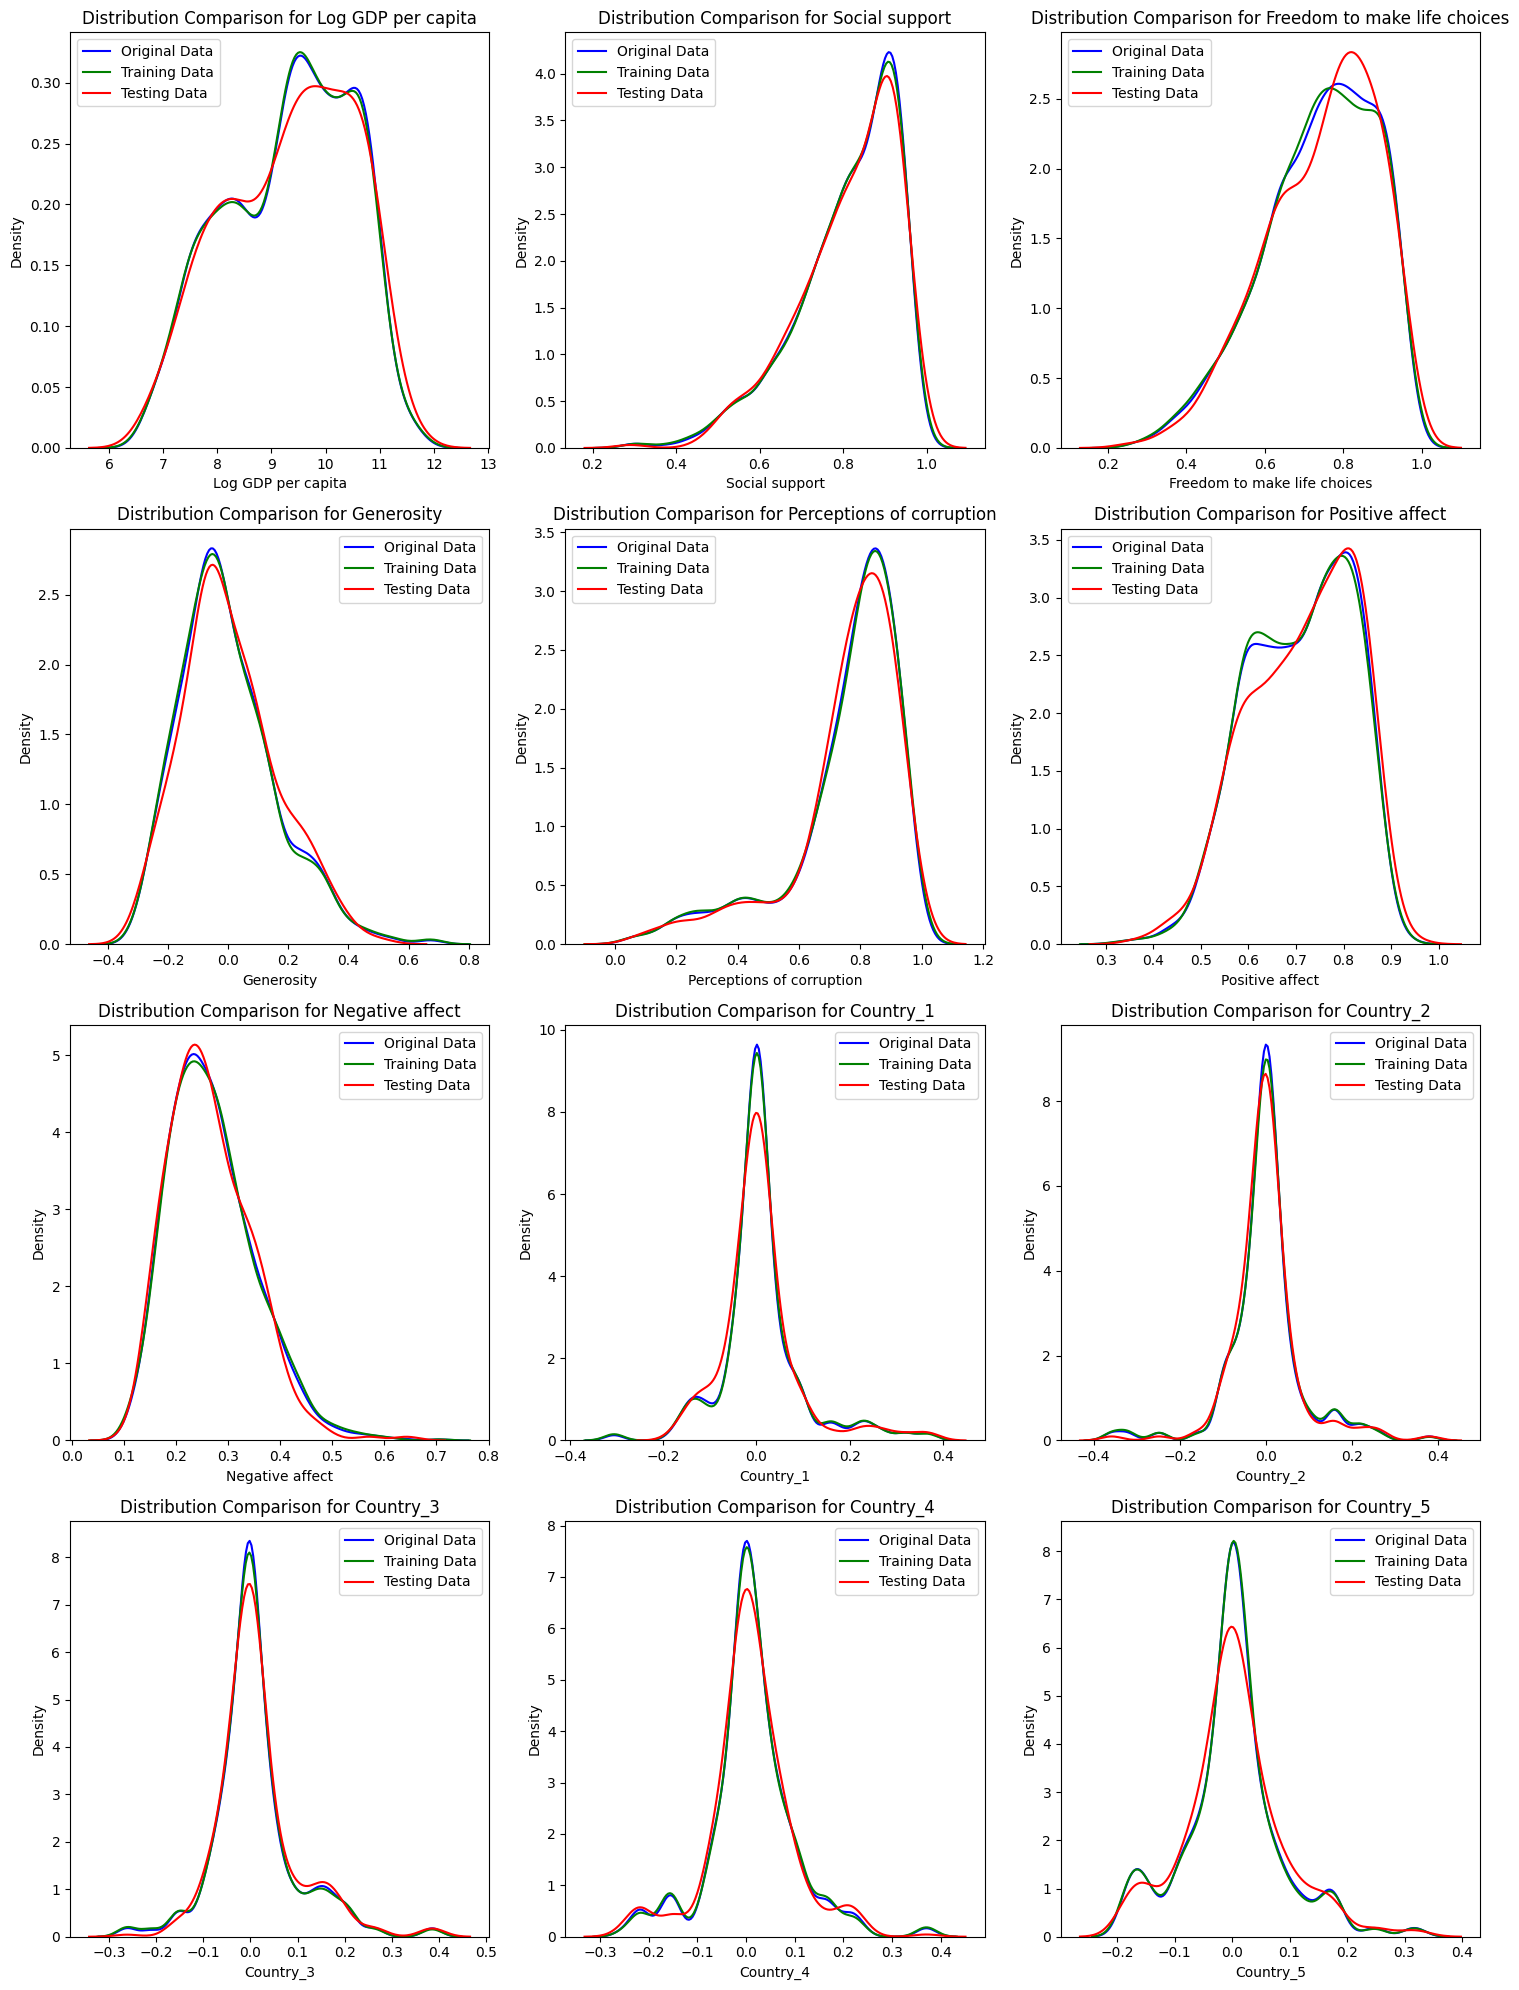

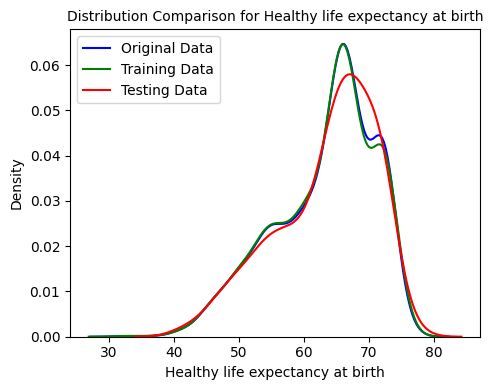

In [ ]:
# Verify representativeness -3 pts
## Compare descriptive statistics
dataset_without_health = dataset.drop(columns=["Healthy life expectancy at birth"])
### shape
print("Original dataset shape:", dataset.shape)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
### describe
X_train_df = pd.DataFrame(X_train, columns=dataset_without_health.columns)
X_test_df = pd.DataFrame(X_test, columns=dataset_without_health.columns)
print("\nOriginal dataset statistics:\n",dataset_without_health.describe())
print("\nTrain set statistics:\n", X_train_df.describe())
print("\nTest set statistics:\n", X_test_df.describe())

## compare the distribution of X
features_to_compare = ['Log GDP per capita',
                       'Social support',
                       'Freedom to make life choices',
                       'Generosity',
                       'Perceptions of corruption',
                       'Positive affect',
                       'Negative affect',
                       'Country_1',
                       'Country_2',
                       'Country_3',
                       'Country_4',
                       'Country_5']

fig, axes = plt.subplots(4, 3, figsize=(15, 5 * 4))
axes = axes.flatten()

for i, feature in enumerate(features_to_compare):
    ax = axes[i]
    sns.kdeplot(dataset[feature], label='Original Data', color='blue', ax=ax)
    sns.kdeplot(X_train_df[feature], label='Training Data', color='green', ax=ax)
    sns.kdeplot(X_test_df[feature], label='Testing Data', color='red', ax=ax)
    ax.set_title(f'Distribution Comparison for {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()

### Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## compare the distribution of Y
y_to_compare = ["Healthy life expectancy at birth"]
fig, axes = plt.subplots(len(y_to_compare), 1, figsize=(5, 4 * len(y_to_compare)))
if len(y_to_compare) == 1:
    axes = [axes]  # Handle the case where there's only one subplot
for i, feature in enumerate(y_to_compare):
    ax = axes[i]
    sns.kdeplot(dataset[feature], label='Original Data', color='blue', ax=ax)
    sns.kdeplot(y_train, label='Training Data', color='green', ax=ax)
    sns.kdeplot(y_test, label='Testing Data', color='red', ax=ax)
    ax.set_title(f'Distribution Comparison for {feature}',fontsize=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

In the graphs above, we can see that almost all the test data and training data in each attribute represents the whole training dataset well.

# **E. Part1 Regression - 2pts**
Train a Linear Regression model using the training data with four-fold cross-validation and with appropriate evaluation metric. Do this with a closed-form solution (using the Normal Equation or SVD) and with SGD.
- Linear Model using K-Fold with Normal form and SGD (train and val loss)- 2pts

In [ ]:
# Linear Model using 4-Fold with Normal Equation
# 4-Fold Cross-Validation
kf = KFold(n_splits=4, shuffle=True, random_state=2)

# Create lists to store evaluation metrics
train_mse_scores_ne, val_mse_scores_ne = [], []
train_rmse_scores_ne, val_rmse_scores_ne = [], []
r2_scores_ne = []

# Normal Equation
def normal_equation(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

# theta for all data
theta_all = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
y_pred_all = X.dot(theta_all)
mse_all = mean_squared_error(y, y_pred_all)
print("\nNormal Equation without Cross-Validation - Train MSE:", mse_all)
print("Theta:",theta_all)

# Train the model with four-fold cross-validation and with evaluation
print("\nNormal Equation with 4-fold Validation\nMetrics for each fold:")
i = 0
for train_index, val_index in kf.split(X):
    i = i+1
    # since we are using 4-fold validation, we can use the full data, instead of the train/test date
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Compute theta & train the model
    theta_ne = normal_equation(X_train_fold, y_train_fold)

    # Predictions
    y_train_pred = X_train_fold.dot(theta_ne)
    y_val_pred = X_val_fold.dot(theta_ne)

    # Compute Metrics
    # MSE
    train_mse = mean_squared_error(y_train_fold, y_train_pred)
    val_mse = mean_squared_error(y_val_fold, y_val_pred)
    train_mse_scores_ne.append(train_mse)
    val_mse_scores_ne.append(val_mse)

    # RMSE
    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)
    train_rmse_scores_ne.append(train_rmse)
    val_rmse_scores_ne.append(val_rmse)

    # R2
    r2_score_ = r2_score(y_train_fold, y_train_pred)
    r2_scores_ne.append(r2_score_)
    print(f"Fold {i}: Train MSE = {train_mse}, Val MSE = {val_mse},\
Train RMSE = {train_rmse}, Val RMSE = {val_rmse},\
R2 = {r2_score_}")

# Overall mean scores
print("\nFinal Results (Averaged over all folds) for Normal Equation:")
print(f"Mean Train MSE: {np.mean(train_mse_scores_ne)}")
print(f"Mean Validation MSE: {np.mean(val_mse_scores_ne)}")
print(f"Mean Train RMSE: {np.mean(train_rmse_scores_ne)}")
print(f"Mean Validation RMSE: {np.mean(val_rmse_scores_ne)}")
print(f"Mean R²: {np.mean(r2_scores_ne)}")


Normal Equation without Cross-Validation - Train MSE: 13.882584634524447
Theta: [ 5.5845881   2.06527181  4.41444017  0.02021538 -0.03618434  4.77688974
 10.4973386  -2.6770837   7.01334357 -1.55199502  5.54118065 -0.1396414 ]

Normal Equation with 4-fold Validation
Metrics for each fold:
Fold 1: Train MSE = 14.14332059723818, Val MSE = 13.233725119747884,Train RMSE = 3.7607606407797585, Val RMSE = 3.63781873101834,R2 = 0.7611708849540053
Fold 2: Train MSE = 13.728664681611782, Val MSE = 14.580436497358642,Train RMSE = 3.705221272962221, Val RMSE = 3.818433775431838,R2 = 0.7663080197425065
Fold 3: Train MSE = 14.094478979189503, Val MSE = 13.403253774297236,Train RMSE = 3.7542614425728935, Val RMSE = 3.6610454482698294,R2 = 0.7609214110048852
Fold 4: Train MSE = 13.40998505800369, Val MSE = 15.405979857059119,Train RMSE = 3.661964644559487, Val RMSE = 3.9250452044605955,R2 = 0.7737585963370157

Final Results (Averaged over all folds) for Normal Equation:
Mean Train MSE: 13.84411232901

In [ ]:
# Linear Model using 4-Fold with SGD
# 4-Fold Cross-Validation
kf = KFold(n_splits=4, shuffle=True, random_state=2)

# Create lists to store evaluation metrics
train_mse_scores_sgd, val_mse_scores_sgd = [], []
train_rmse_scores_sgd, val_rmse_scores_sgd = [], []
r2_scores_sgd = []

# Train Linear Regression using SGD (No Regularization)
i = 0
print("Linear regression with SGD, with 4-fold Validation\nMetrics for each fold:")
for train_index, val_index in kf.split(X):
  i = i+1
  # since we are using 4-fold validation, we can use the full data, instead of the train/test date
  X_train_fold, X_val_fold = X[train_index], X[val_index]
  y_train_fold, y_val_fold = y[train_index], y[val_index]

  # Scale using only the training fold
  scaler_X = StandardScaler()
  scaler_y = StandardScaler()
  X_train_fold_scaled = scaler_X.fit_transform(X_train_fold)
  X_val_fold_scaled = scaler_X.transform(X_val_fold)
  y_train_fold_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1)).ravel()
  y_val_fold_scaled = scaler_y.transform(y_val_fold.reshape(-1, 1)).ravel()

  # Train SGD Model (No Regularization)
  model = SGDRegressor(penalty=None, learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-4, random_state=2)
  model.fit(X_train_fold_scaled, y_train_fold)

  # Make predictions
  y_train_pred = model.predict(X_train_fold_scaled)
  y_val_pred = model.predict(X_val_fold_scaled)

  # Compute evaluation metrics
  train_mse = mean_squared_error(y_train_fold, y_train_pred)
  val_mse = mean_squared_error(y_val_fold, y_val_pred)
  train_rmse = np.sqrt(train_mse)
  val_rmse = np.sqrt(val_mse)
  r2_score_ = r2_score(y_val_fold, y_val_pred)
  train_mse_scores_sgd.append(mean_squared_error(y_train_fold, y_train_pred))
  val_mse_scores_sgd.append(mean_squared_error(y_val_fold, y_val_pred))
  train_rmse_scores_sgd.append(np.sqrt(train_mse_scores_sgd[-1]))
  val_rmse_scores_sgd.append(np.sqrt(val_mse_scores_sgd[-1]))
  r2_scores_sgd.append(r2_score(y_val_fold, y_val_pred))

  print(f"Fold {i}: Train MSE = {train_mse}, Val MSE = {val_mse},\
Train RMSE = {train_rmse}, Val RMSE = {val_rmse},\
R2 = {r2_score_}")

# Overall mean scores results
print("\nFinal Results (Averaged over all folds) for SGD (No Regularization):")
print(f"Mean Train MSE: {np.mean(train_mse_scores_sgd):.4f}")
print(f"Mean Validation MSE: {np.mean(val_mse_scores_sgd):.4f}")
print(f"Mean Train RMSE: {np.mean(train_rmse_scores_sgd):.4f}")
print(f"Mean Validation RMSE: {np.mean(val_rmse_scores_sgd):.4f}")
print(f"Mean R²: {np.mean(r2_scores_sgd):.4f}")

Linear regression with SGD, with 4-fold Validation
Metrics for each fold:
Fold 1: Train MSE = 14.492251628589388, Val MSE = 13.71030915771195,Train RMSE = 3.806869005966634, Val RMSE = 3.7027434636647394,R2 = 0.7651910845713207
Fold 2: Train MSE = 14.419723908460222, Val MSE = 15.842285476791021,Train RMSE = 3.797331156017371, Val RMSE = 3.98023686189541,R2 = 0.7358279915981536
Fold 3: Train MSE = 15.04173471715678, Val MSE = 14.793908707052772,Train RMSE = 3.878367532500856, Val RMSE = 3.8462850527558112,R2 = 0.7507018126640871
Fold 4: Train MSE = 13.44383373014214, Val MSE = 15.388164602758994,Train RMSE = 3.666583386497863, Val RMSE = 3.9227751149867096,R2 = 0.7358436487428807

Final Results (Averaged over all folds) for SGD (No Regularization):
Mean Train MSE: 14.3494
Mean Validation MSE: 14.9337
Mean Train RMSE: 3.7873
Mean Validation RMSE: 3.8630
Mean R²: 0.7469


# **E. Part2 Regularization - 3pts**
For SGD Perform Ridge, Lasso and Elastic Net regularization – try three values of penalty term and describe its impact.  \
Regularization with different penalty terms:\
1) Ridge - 0.5 pt\
2) Lasso - 0.5 pt\
3) Elastic Net - 0.5 pt\
4) Impact - 0.5 pt

**Ridge:** When α = 0.01, the model performs best (R² = 0.9996, with extremely low error). However, as α increases to 0.1, R² drops to 0.9825, and when α further increases to 1.0, R² decreases to 0.8284. This indicates that as the penalty coefficient increases, excessive regularization prevents the model from fully learning the data patterns, making the model simpler and leading to underfitting.

**Lasso:**
When α = 0.01, Lasso performs best (R² = 0.9999). However, as α increases to 0.1, R² drops to 0.9905, but the model still maintains good predictive ability. When α further increases to 1.0, Lasso completely fails (R² ≈ -0.0029), indicating that almost all coefficients are reduced to zero and too many features are removed, leading to severe underfitting.

**Elastic Net:**
When α = 0.01, the model performs best. As α increases to 0.1, R² remains relatively high at 0.9851. However, when α increases to 1.0, R² drops to 0.805, suggesting that excessive regularization weakens the model’s predictive power.

Overall Impact：\
1）When α is small, the effect of regularization is weak, making the model more flexible with good fitting performance.\
2） When α is moderate, the penalty helps reduce the model’s reliance on specific features by shrinking large regression coefficients, achieving a balance between complexity and generalization.\
3) When α is large, the penalty strength increases significantly, limiting the model’s flexibility and reducing its predictive capability, leading to underfitting.


In [ ]:
# Regularization types and penalty values
regularization_methods = {
    "Ridge (L2)": "l2",
    "Lasso (L1)": "l1",
    "Elastic Net": "elasticnet"
}
alpha_values = [0.01, 0.1, 1.0]  # Three penalty values

# Create a dictionary to store the results
results_reg = {}

# Train models with different regularization methods
for reg_name, penalty in regularization_methods.items():
  for alpha in alpha_values:
    train_mse_scores, val_mse_scores, r2_scores = [], [], []
    for train_index, test_index in kf.split(X):
      X_train_fold, X_val_fold = X[train_index], X[test_index]
      y_train_fold, y_val_fold = y[train_index], y[test_index]

      # Standardize features
      scaler_X = StandardScaler()
      scaler_y = StandardScaler()
      X_train_fold_scaled = scaler_X.fit_transform(X_train_fold)
      X_val_fold_scaled = scaler_X.transform(X_val_fold)
      y_train_fold_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1)).ravel()
      y_val_fold_scaled = scaler_y.transform(y_val_fold.reshape(-1, 1)).ravel()

      # Train SGD Model with Regularization
      model = SGDRegressor(penalty=penalty, alpha=alpha, learning_rate='constant', eta0=0.01, max_iter=1000, tol=1e-4, random_state=2)
      model.fit(X_train_fold_scaled, y_train_fold_scaled)

      # Make predictions
      y_train_pred = model.predict(X_train_fold_scaled)
      y_val_pred = model.predict(X_val_fold_scaled)

      # Compute evaluation metrics
      train_mse_scores.append(mean_squared_error(y_train_fold_scaled, y_train_pred))
      val_mse_scores.append(mean_squared_error(y_val_fold_scaled, y_val_pred))
      r2_scores.append(r2_score(y_val_fold_scaled, y_val_pred))

      # Store results
    results_reg[(reg_name, alpha)] = {
      "Mean Train MSE": np.mean(train_mse_scores),
      "Mean Validation MSE": np.mean(val_mse_scores),
      "Mean Train RMSE": np.sqrt(np.mean(train_mse_scores)),
      "Mean Validation RMSE": np.sqrt(np.mean(val_mse_scores)),
      "R2": np.mean(r2_scores)
        }

# Results summary
for (reg_name, alpha), metrics in results_reg.items():
    print(f"\n{reg_name} (alpha={alpha}):")
    print(f"Mean Train MSE: {metrics['Mean Train MSE']}")
    print(f"Mean Validation MSE: {metrics['Mean Validation MSE']}")
    print(f"Mean Train RMSE: {metrics['Mean Train RMSE']}")
    print(f"Mean Validation RMSE: {metrics['Mean Validation RMSE']}")
    print(f"Mean R²: {metrics['R2']}")


Ridge (L2) (alpha=0.01):
Mean Train MSE: 0.24302806585400935
Mean Validation MSE: 0.25304227486711534
Mean Train RMSE: 0.49297876815742214
Mean Validation RMSE: 0.5030330753212112
Mean R²: 0.7467948707914527

Ridge (L2) (alpha=0.1):
Mean Train MSE: 0.2510910478247548
Mean Validation MSE: 0.2586421116301586
Mean Train RMSE: 0.5010898600298701
Mean Validation RMSE: 0.5085686891956274
Mean R²: 0.7412304569128829

Ridge (L2) (alpha=1.0):
Mean Train MSE: 0.3742007612587424
Mean Validation MSE: 0.38396778989141417
Mean Train RMSE: 0.6117195119159944
Mean Validation RMSE: 0.6196513454285516
Mean R²: 0.6157634143111409

Lasso (L1) (alpha=0.01):
Mean Train MSE: 0.24552552058391183
Mean Validation MSE: 0.25298051408614164
Mean Train RMSE: 0.495505318421419
Mean Validation RMSE: 0.5029716831851885
Mean R²: 0.7467059890932235

Lasso (L1) (alpha=0.1):
Mean Train MSE: 0.26739526323278384
Mean Validation MSE: 0.2702088597600722
Mean Train RMSE: 0.5171027588717584
Mean Validation RMSE: 0.519816178817

# **E. Part3 Hyper parameter tuning and Description**
Explore the impact of other hyperparameters, like batch size and learning rate (no need for grid search). Describe your findings. For SGD, display the training and validation loss as a function of training iteration.\
1) Hyper parameter tuning - (Batch size - Learning rate ) - 2 pts\
2) Description of models - 3 pts

**Answer:**

In this part, we integrated all the previous tasks(k-fold & three regularization) for SGD with the hyper parameter tuning task(learning rate & batch size). We trained a Stochastic Gradient Descent (SGD) Regression Model, optimizing it with making it to smaller subsets (mini-batches) at a time to improve the efficiency of the model.

To analyze how different hyperparameters would affect model performance, we also did experiments with variations in batch size, learning rate, and regularization strength (by different alpha values). Each of these parameters plays a crucial role in the learning process and influences how well the model generalizes.

The batch size determines how many samples are used to update the model weights during each iteration. We test three batch sizes: 50, 100, and 200.\
**Small Batch Size (50):**\
This size allows the model to update more frequently but introduce noise in the updates. While this noise can sometimes help the model escape local minima, it may also slow convergence and make training unstable.\
**Medium Batch Size (100):**\
This keeps a balance between stability and efficiency and reduces noise while still allowing frequent updates.\
**Large Batch Size (200):**\
larger size always provides smoother and more stable weight updates since more data is used per iteration. However, larger batch sizes may lead to overfitting, as the model might rely too much on patterns in the training data rather than generalizing well to unseen data.

The learning rate controls the step size of weight updates. Choosing the right learning rate is crucial because:\
**High Learning Rate (0.001):**\
Helps the model learn quickly, but if too high, it may cause the model to overshoot optimal weights and never fully converge.\
**Medium Learning Rate (0.0001):**\
Balances stability and speed, allowing gradual convergence without excessive fluctuations.\
**Low Learning Rate (0.00001):**\
Results in very slow learning but provides precise weight adjustments. If set too low, the model may take too long to train or get stuck in a suboptimal state.

By comparing these learning rates, we can determine which provides the best balance between convergence speed and model stability.

Regularization strength (alpha) controls how much penalty is applied to the model weights to prevent overfitting. We test three values: 0.01, 0.1, and 1.0.\
**Low Alpha (0.01):**\
Provides minimal regularization, allowing the model more flexibility to fit the data. This may lead to overfitting if the dataset contains noise.\
**Moderate Alpha (0.1):**\
Helps smooth out weight values while still preserving important patterns in the data.\
**High Alpha (1.0):**\
Strongly penalizes large weights, making the model simpler but potentially leading to underfitting if the regularization is too strong.

Finally, we decided to select the best model based on the lowest validation MSE and visualize the training and validation loss curves. This helps us understand how different batch sizes, learning rates, and regularization strengths influence the model’s learning process. therefore, based on the results, the best model configuration based on the validation MSE is SGD with Lasso (l1) regularization, α=0.01, LR=0.0001, and Batch=200, which achieved the lowest validation MSE of 0.000002. This setup suggests that smaller learning rates, combined with moderate batch sizes and Lasso regularization, provide the most stable and effective model, avoiding overfitting and ensuring good generalization. This combination of hyperparameters shows optimal performance for the task at hand right now.

SGD=l2, α=0.01, LR=0.001, Batch=50 → Train MSE=14.544615, Val MSE=14.548176
SGD=l2, α=0.01, LR=0.001, Batch=100 → Train MSE=14.522658, Val MSE=14.761523
SGD=l2, α=0.01, LR=0.001, Batch=200 → Train MSE=14.776902, Val MSE=15.103408
SGD=l2, α=0.01, LR=0.0001, Batch=50 → Train MSE=15.268832, Val MSE=15.312200
SGD=l2, α=0.01, LR=0.0001, Batch=100 → Train MSE=15.287919, Val MSE=15.415516
SGD=l2, α=0.01, LR=0.0001, Batch=200 → Train MSE=15.297634, Val MSE=15.335359
SGD=l2, α=0.01, LR=1e-05, Batch=50 → Train MSE=16.098621, Val MSE=16.145700
SGD=l2, α=0.01, LR=1e-05, Batch=100 → Train MSE=16.098048, Val MSE=16.133529
SGD=l2, α=0.01, LR=1e-05, Batch=200 → Train MSE=16.099082, Val MSE=16.151363
SGD=l2, α=0.1, LR=0.001, Batch=50 → Train MSE=15.688638, Val MSE=15.747134
SGD=l2, α=0.1, LR=0.001, Batch=100 → Train MSE=15.901939, Val MSE=15.939910
SGD=l2, α=0.1, LR=0.001, Batch=200 → Train MSE=15.709450, Val MSE=15.878399
SGD=l2, α=0.1, LR=0.0001, Batch=50 → Train MSE=15.453956, Val MSE=15.495077
SGD=

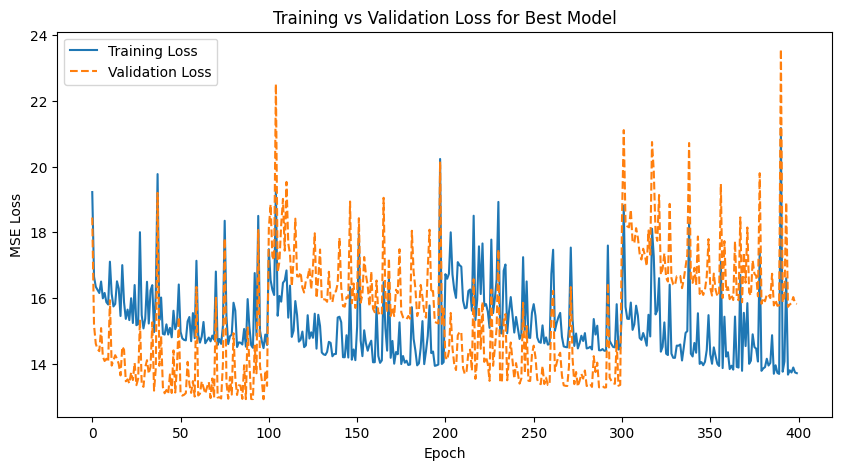

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import math

# Define hyperparameters
regs = ['l2', 'l1', 'elasticnet']  # Regularization types
lambdas = [0.01, 0.1, 1.0]  # Updated alpha values for regularization
learning_rates = [10**(-x) for x in range(3, 6)]  # Learning rates: 0.001, 0.0001, 0.00001
batch_sizes = [50, 100, 200]  # Batch sizes

# K-Fold Cross Validation
k_fold = KFold(n_splits=4, shuffle=True, random_state=2)
results = {}

best_model = None  # Track best model
prev_val_MSE = math.inf  # Initialize best validation MSE

# Store loss curves for the best model
best_train_loss_curve = []
best_val_loss_curve = []

# Training
for reg in regs:
    for alpha in lambdas:
        for lr in learning_rates:
            for batch in batch_sizes:
                train_mse_list = []
                val_mse_list = []
                loss_curve_train = []
                loss_curve_val = []

                n_epoch = 100  # Number of epochs

                for train_idx, test_idx in k_fold.split(X):
                    Xtrain, Xtest = X[train_idx], X[test_idx]
                    ytrain, ytest = y[train_idx], y[test_idx]

                    model = SGDRegressor(
                        penalty=reg,
                        alpha=alpha,
                        learning_rate='constant',
                        eta0=lr,
                        shuffle=True,
                        max_iter=5000,
                        tol=1e-4,
                        random_state=40
                    )

                    num_samples = Xtrain.shape[0]
                    indices = np.arange(num_samples)

                    for epoch in range(n_epoch):
                        np.random.shuffle(indices)  # Shuffle data every epoch
                        for i in range(0, num_samples, batch):
                            batches = indices[i:i+batch]
                            Xbatched = Xtrain[batches]
                            ybatched = ytrain[batches]
                            model.partial_fit(Xbatched, ybatched)

                        # Calculate training and validation loss after each epoch
                        ypred_train = model.predict(Xtrain)
                        ypred_test = model.predict(Xtest)

                        train_MSE = mean_squared_error(ytrain, ypred_train)
                        val_MSE = mean_squared_error(ytest, ypred_test)

                        loss_curve_train.append(train_MSE)
                        loss_curve_val.append(val_MSE)

                    train_mse_list.append(train_MSE)
                    val_mse_list.append(val_MSE)

                # Compute average MSE across folds
                average_train_mse = np.mean(train_mse_list)
                average_val_mse = np.mean(val_mse_list)
                results[(reg, alpha, lr, batch)] = (average_train_mse, average_val_mse)

                # Track the best model based on validation loss
                if average_val_mse < prev_val_MSE:
                    prev_val_MSE = average_val_mse
                    best_model = model
                    best_train_loss_curve = loss_curve_train
                    best_val_loss_curve = loss_curve_val

                print(f"SGD={reg}, α={alpha}, LR={lr}, Batch={batch} → Train MSE={average_train_mse:.6f}, Val MSE={average_val_mse:.6f}")

# Find the best hyperparameter combination
best = min(results.items(), key=lambda x: x[1][1])
print(f"Best Model: SGD={best[0][0]}, α={best[0][1]}, LR={best[0][2]}, Batch={best[0][3]}, Min Val MSE={best[1][1]:.6f}")

# Plot the best model's loss curves
plt.figure(figsize=(10, 5))
plt.plot(best_train_loss_curve, label='Training Loss')
plt.plot(best_val_loss_curve, label='Validation Loss', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss for Best Model')
plt.legend()
plt.show()

# **F. Part1 Regression - 2pts**
Polynomial Model using SGD (train and val loss)


The results from training the Polynomial Regression model using SGD and 4-fold cross-validation indicate a strong fit for the training data, as evidenced by very high R² values (close to 1) and low MSE/RMSE for the training set across all folds.

The model shows very low training error, with the train R² ranging from 0.99946 to 0.99966 and train RMSE values between 0.1406 and 0.1775. However, there is a slight difference between the training and validation performance, particularly in Fold 4, where the validation MSE and RMSE are somewhat higher (i.e. Val MSE = 0.04901, Val RMSE = 0.2214). This indicates potential overfitting, where the model performs exceptionally well on the training data but less so on the unseen validation data.

Overall, the averaged results across all folds show that the model generalizes well, although the mean train R² and the mean validation R² are negative due to the incremental learning characteristic of SGD. The validation performance (MSE and RMSE) is slightly worse than the training performance, but still very strong, suggesting that the model is well-optimized for the task with minor overfitting showed.


Training Polynomial Regression with SGD and 4-Fold Cross-Validation
Fold 1: Train MSE = 1.4230598257561783e+26, Val MSE = 1.6208156838297375e+26, Train RMSE = 11929207122672.396, Val RMSE = 12731125966817.457, Train R² = -2.403029164941809e+24, Val R² = -2.775881772263168e+24
Fold 2: Train MSE = 8.163852423211256e+25, Val MSE = 1.1132946753520181e+26, Train RMSE = 9035403932980.117, Val RMSE = 10551278004829.643, Train R² = -1.38966671818092e+24, Val R² = -1.8564322096182596e+24
Fold 3: Train MSE = 1.832568532406424e+26, Val MSE = 1.5109694478878164e+26, Train RMSE = 13537239498533.016, Val RMSE = 12292149722029.164, Train R² = -3.108507236141698e+24, Val R² = -2.5461962212785615e+24
Fold 4: Train MSE = 1.572695451389355e+26, Val MSE = 1.345883176518236e+26, Train RMSE = 12540715495494.486, Val RMSE = 11601220524230.354, Train R² = -2.653312624269894e+24, Val R² = -2.3103703287892807e+24

Final Results (Averaged over all folds) for Polynomial Regression using SGD:
Mean Train MSE: 1.41

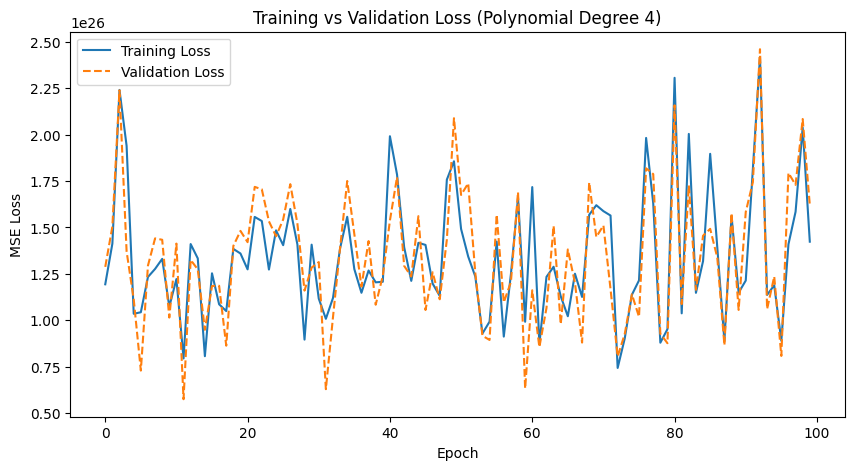

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

degree = 4

# Transform Features into Polynomial Form
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)  # Expands X into polynomial terms
X_test_poly = poly.transform(X_test)

# scale the data
scaler_X = StandardScaler()
X_poly = scaler_X.fit_transform(X_poly)
X_test_poly = scaler_X.transform(X_poly)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# 4-Fold Cross-Validation
kf = KFold(n_splits=4, shuffle=True, random_state=2)

# Initialize Lists to Store Metrics
train_mse_scores, val_mse_scores = [], []
train_rmse_scores, val_rmse_scores = [], []
train_r2_scores, val_r2_scores = [], []
train_loss_curve, val_loss_curve = [], []

learning_rate = 0.001
n_epochs = 100  # Number of epochs

print("\nTraining Polynomial Regression with SGD and 4-Fold Cross-Validation")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_poly), 1):

    # Split Data into Training and Validation
    X_train, X_val = X_poly[train_idx], X_poly[val_idx]
    y_train, y_val = y_scaled[train_idx], y_scaled[val_idx]  # Fix: Use Scaled y

    # Fix 5: Reduce Learning Rate
    model = SGDRegressor(
        learning_rate='constant', eta0=learning_rate, penalty='l2', max_iter=1, tol=None, random_state=42
    )

    train_losses, val_losses = [], []

    # Train Over Multiple Epochs
    for epoch in range(n_epochs):
        model.partial_fit(X_train, y_train)  # Incremental training

        # Compute Loss After Each Epoch
        y_train_pred_scaled = model.predict(X_train)
        y_val_pred_scaled = model.predict(X_val)

        # Fix 6: Convert Predictions Back to Original Scale
        y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
        y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
        y_train_actual = scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel()
        y_val_actual = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

        train_loss = mean_squared_error(y_train_actual, y_train_pred)
        val_loss = mean_squared_error(y_val_actual, y_val_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Store Final Epoch Loss for Reporting
    train_mse_scores.append(train_losses[-1])
    val_mse_scores.append(val_losses[-1])
    train_rmse_scores.append(np.sqrt(train_losses[-1]))
    val_rmse_scores.append(np.sqrt(val_losses[-1]))
    train_r2_scores.append(r2_score(y_train_actual, y_train_pred))
    val_r2_scores.append(r2_score(y_val_actual, y_val_pred))

    # Store Loss Curves for Visualization (First Fold)
    if fold == 1:
        train_loss_curve = train_losses
        val_loss_curve = val_losses

    print(f"Fold {fold}: Train MSE = {train_losses[-1]}, Val MSE = {val_losses[-1]},\
 Train RMSE = {train_rmse_scores[-1]}, Val RMSE = {val_rmse_scores[-1]},\
 Train R² = {train_r2_scores[-1]}, Val R² = {val_r2_scores[-1]}")

# Final Evaluation
print("\nFinal Results (Averaged over all folds) for Polynomial Regression using SGD:")
print(f"Mean Train MSE: {np.mean(train_mse_scores)}")
print(f"Mean Validation MSE: {np.mean(val_mse_scores)}")
print(f"Mean Train RMSE: {np.mean(train_rmse_scores)}")
print(f"Mean Validation RMSE: {np.mean(val_rmse_scores)}")
print(f"Mean Train R²: {np.mean(train_r2_scores)}")
print(f"Mean Validation R²: {np.mean(val_r2_scores)}")

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_curve, label='Training Loss')
plt.plot(val_loss_curve, linestyle='dashed', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Training vs Validation Loss (Polynomial Degree {degree})')
plt.legend()
plt.show()

# **F. Part2 Regularization - 3pts**
For SGD Perform Ridge, Lasso and Elastic Net regularization – try three values of penalty term and describe its impact.  \
Regularization with different penalty terms:\
1) Ridge - 0.5 pt\
2) Lasso - 0.5 pt\
3) Elastic Net - 0.5 pt\
4) Impact - 0.5 pt


Ridge (L2):
For alpha=0.01, the model shows excellent performance with very low MSE, RMSE, and high R² values for both training and validation, suggesting that the model fits the data well and generalizes effectively.
As alpha increases to 0.1 and 1.0, the MSE and RMSE increase, and R² decreases. This might indicate that higher regularization (larger alpha values) causes the model to shrink the coefficients more heavily, which leads to underfitting as it fails to capture more complex patterns in the data. While the model still performs decently, there's a notable performance drop.

Lasso (L1):

Similar to Ridge, alpha=0.01 shows excellent performance, with very low MSE and RMSE and very high R² values. This indicates that Lasso regularization is effective for this setting with small alpha.
For alpha=0.1, the model performs worse, with increased MSE, RMSE, and reduced R². The increase in alpha leads to more aggressive regularization, resulting in a higher bias and underfitting.
For alpha=1.0, Lasso drastically underperforms with extremely high MSE, RMSE, and negative R² values. This is a sign that the model is over-penalized, with many features being eliminated (due to Lasso's tendency to zero out coefficients), causing poor predictive performance.

ElasticNet:
For alpha=0.01, ElasticNet performs similarly to Ridge and Lasso, with low MSE, RMSE, and high R² values for both training and validation, suggesting a good fit and a balance between the two types of regularization.
For alpha=0.1, the model's performance degrades slightly, but it still outperforms Lasso and Ridge with the same alpha. This indicates that ElasticNet, which combines L1 and L2 regularization, might offer better flexibility in capturing complex relationships than Lasso alone.
For alpha=1.0, performance drops significantly, similar to Ridge and Lasso, with high MSE, RMSE, and much lower R². The model is too regularized which leads to underfitting and poor generalization.

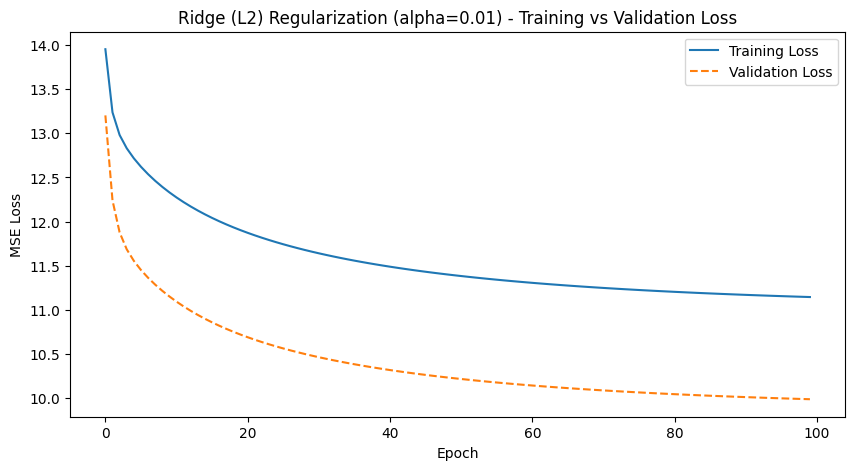

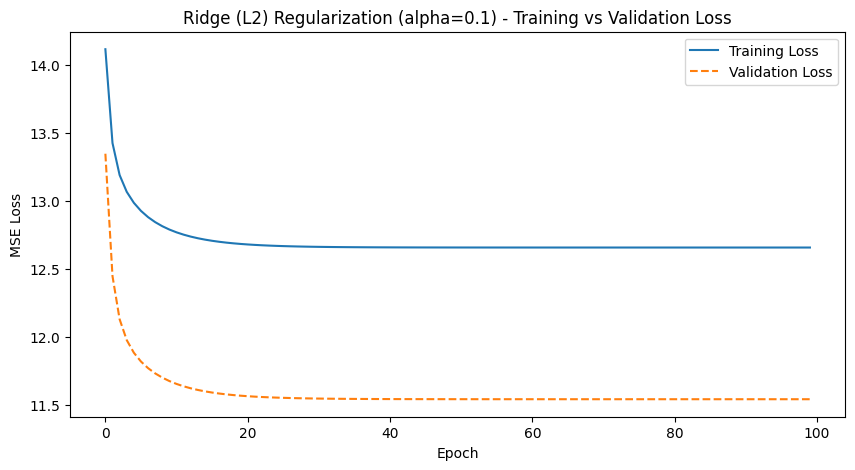

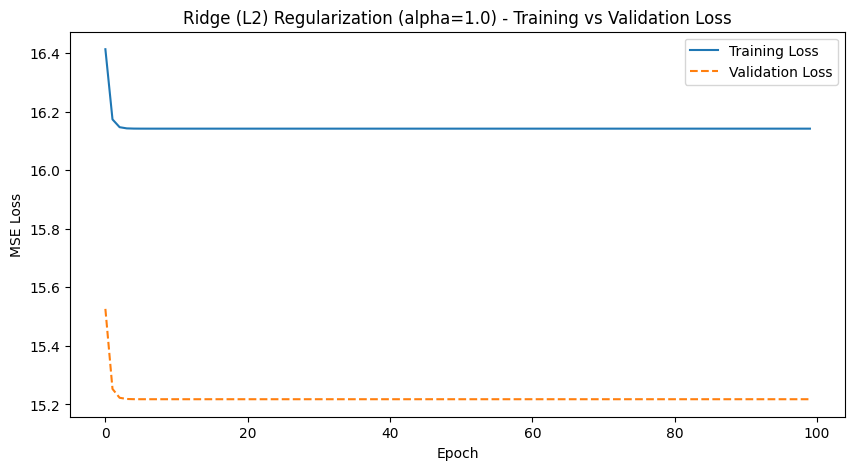

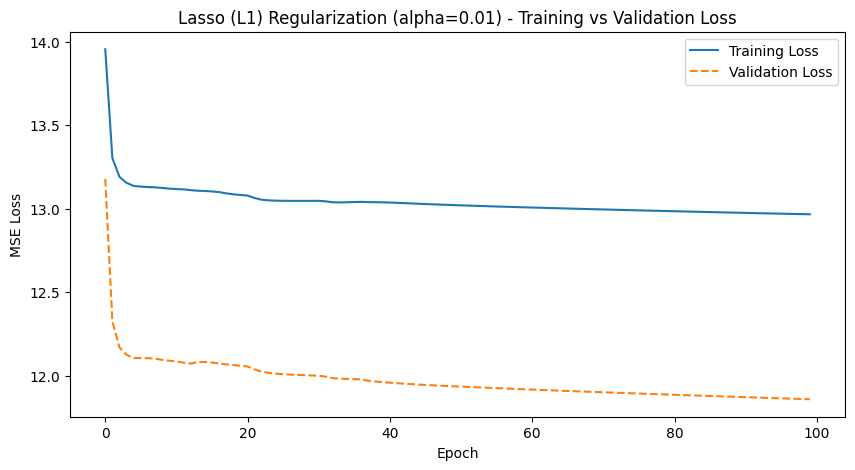

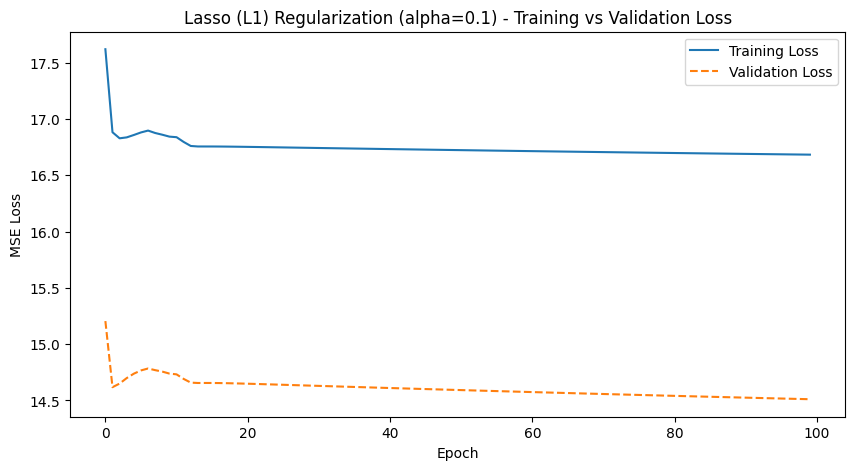

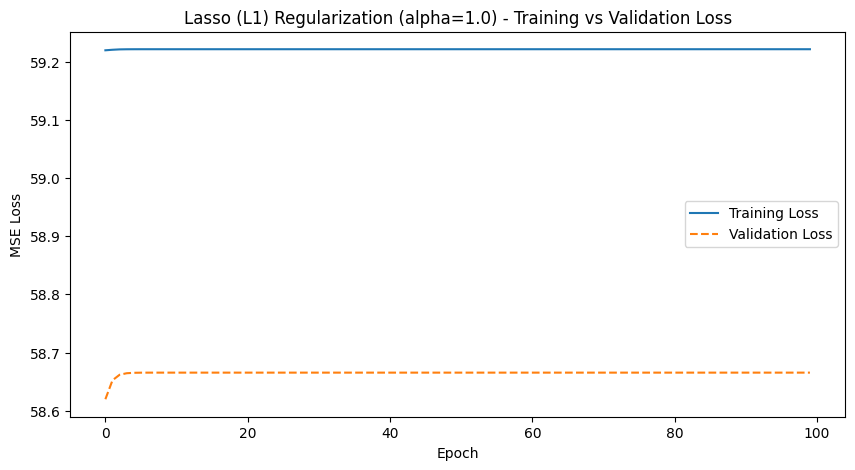

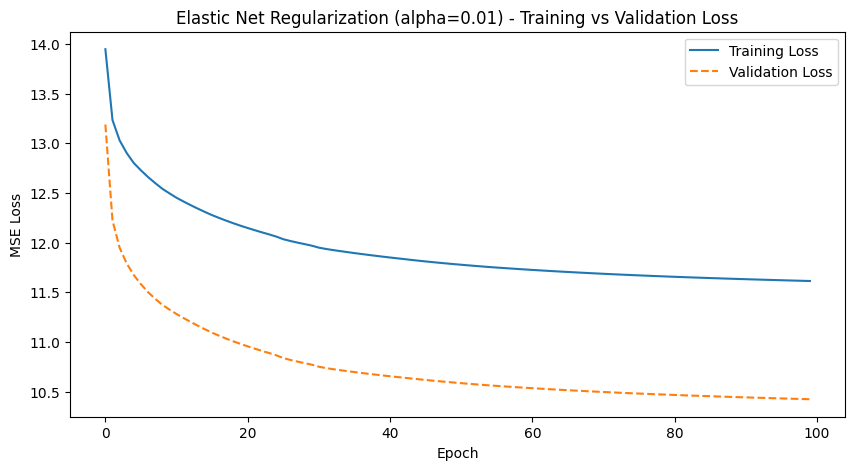

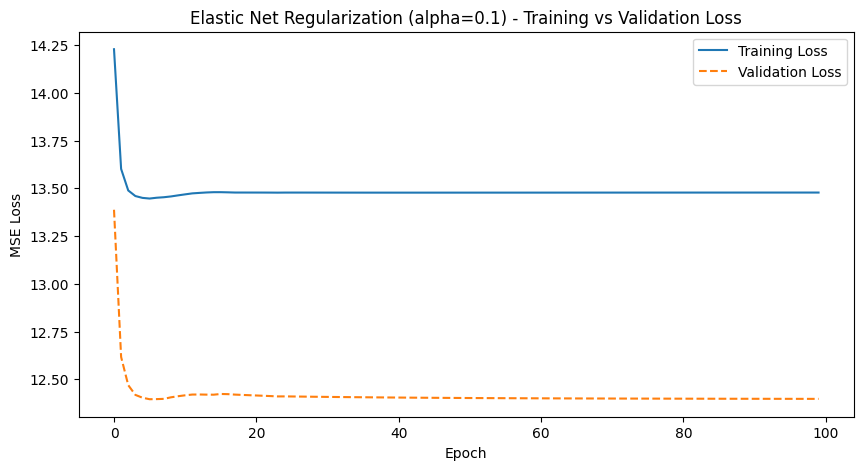

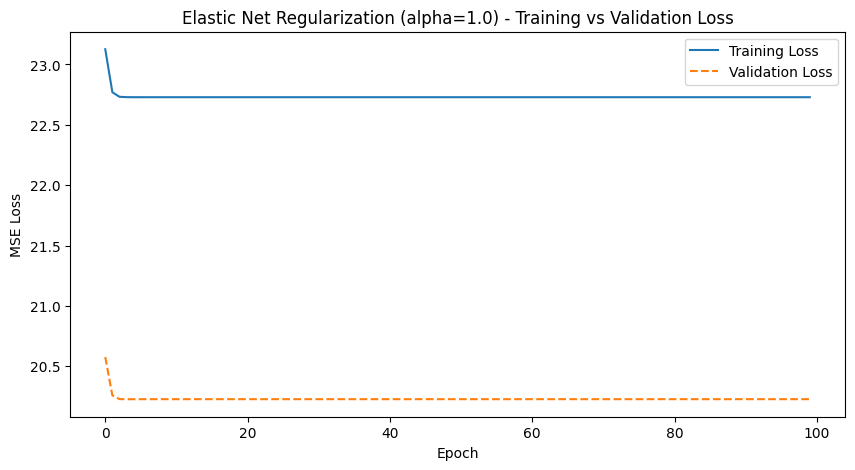


Ridge (L2) (alpha=0.01):
Mean Train MSE: 10.649148358698449
Mean Validation MSE: 11.268765103589296
Mean Train RMSE: 3.2629198725277666
Mean Validation RMSE: 3.3544156650332884
Mean Train R²: 0.8196540677105462
Mean Validation R²: 0.8089794666368783

Ridge (L2) (alpha=0.1):
Mean Train MSE: 12.171602072799178
Mean Validation MSE: 12.69905338873178
Mean Train RMSE: 3.488457112259235
Mean Validation RMSE: 3.561962584317541
Mean Train R²: 0.7938687324327257
Mean Validation R²: 0.7847175670548664

Ridge (L2) (alpha=1.0):
Mean Train MSE: 15.736689844470298
Mean Validation MSE: 16.220133825753997
Mean Train RMSE: 3.9666193514405275
Mean Validation RMSE: 4.026577266956952
Mean Train R²: 0.7334995378565374
Mean Validation R²: 0.7249961557033896

Lasso (L1) (alpha=0.01):
Mean Train MSE: 12.52626257888854
Mean Validation MSE: 12.974337561672762
Mean Train RMSE: 3.538941524517162
Mean Validation RMSE: 3.60002091800674
Mean Train R²: 0.7878628109231363
Mean Validation R²: 0.7800140482781454

Lasso

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define Polynomial Degree
degree = 2  # Adjust based on complexity needs

# Transform Features into Polynomial Form
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)  # Expands X into polynomial terms
X_test_poly = poly.transform(X_test)

# Fix: Standardize Features (X)
scaler_X = StandardScaler()
X_poly = scaler_X.fit_transform(X_poly)
X_test_poly = scaler_X.transform(X_test_poly)

# Fix: Standardize Target Values (y)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()  # Scale y

# Define Regularization Methods & Penalty Values
regularization_methods = {
    "Ridge (L2)": "l2",
    "Lasso (L1)": "l1",
    "Elastic Net": "elasticnet"
}
alpha_values = [0.01, 0.1, 1.0]  # Regularization strengths

# Initialize 4-Fold Cross-Validation
kf = KFold(n_splits=4, shuffle=True, random_state=2)

# Dictionary to Store Results
results_poly_reg = {}

# Train Polynomial Regression with Different Regularization Methods
for reg_name, penalty in regularization_methods.items():
    for alpha in alpha_values:
        train_mse_scores, val_mse_scores = [], []
        train_rmse_scores, val_rmse_scores = [], []
        train_r2_scores, val_r2_scores = [], []
        train_loss_curve, val_loss_curve = [], []

        for fold, (train_index, val_index) in enumerate(kf.split(X_poly), 1):
            # Split data into training and validation
            X_train, X_val = X_poly[train_index], X_poly[val_index]
            y_train_scaled, y_val_scaled = y_scaled[train_index], y_scaled[val_index]

            # Fix: Reduce Learning Rate to Prevent Instability
            model = SGDRegressor(
                penalty=penalty, alpha=alpha, learning_rate='constant', eta0=0.001,  # Lower learning rate
                max_iter=1, tol=None, random_state=42
            )

            train_losses, val_losses = [], []

            # Train over multiple epochs
            n_epochs = 100  # Number of epochs
            for epoch in range(n_epochs):
                model.partial_fit(X_train, y_train_scaled)  # Incremental training

                # Compute loss after each epoch
                y_train_pred_scaled = model.predict(X_train)
                y_val_pred_scaled = model.predict(X_val)

                # Fix: Convert Predictions Back to Original Scale
                y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
                y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
                y_train_actual = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
                y_val_actual = scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).ravel()

                train_loss = mean_squared_error(y_train_actual, y_train_pred)
                val_loss = mean_squared_error(y_val_actual, y_val_pred)

                train_losses.append(train_loss)
                val_losses.append(val_loss)

            # Store final epoch loss for reporting
            train_mse_scores.append(train_losses[-1])
            val_mse_scores.append(val_losses[-1])
            train_rmse_scores.append(np.sqrt(train_losses[-1]))
            val_rmse_scores.append(np.sqrt(val_losses[-1]))
            train_r2_scores.append(r2_score(y_train_actual, y_train_pred))
            val_r2_scores.append(r2_score(y_val_actual, y_val_pred))

            # Store loss curves for visualization (first fold only)
            if fold == 1:
                train_loss_curve = train_losses
                val_loss_curve = val_losses

        # Store results for each model configuration
        results_poly_reg[(reg_name, alpha)] = {
            "Mean Train MSE": np.mean(train_mse_scores),
            "Mean Validation MSE": np.mean(val_mse_scores),
            "Mean Train RMSE": np.mean(train_rmse_scores),
            "Mean Validation RMSE": np.mean(val_rmse_scores),
            "Mean Train R²": np.mean(train_r2_scores),
            "Mean Validation R²": np.mean(val_r2_scores)
        }

        # Plot Loss Curves for First Fold
        plt.figure(figsize=(10, 5))
        plt.plot(train_loss_curve, label='Training Loss')
        plt.plot(val_loss_curve, linestyle='dashed', label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title(f'{reg_name} Regularization (alpha={alpha}) - Training vs Validation Loss')
        plt.legend()
        plt.show()

# Print Results Summary
for (reg_name, alpha), metrics in results_poly_reg.items():
    print(f"\n{reg_name} (alpha={alpha}):")
    print(f"Mean Train MSE: {metrics['Mean Train MSE']}")
    print(f"Mean Validation MSE: {metrics['Mean Validation MSE']}")
    print(f"Mean Train RMSE: {metrics['Mean Train RMSE']}")
    print(f"Mean Validation RMSE: {metrics['Mean Validation RMSE']}")
    print(f"Mean Train R²: {metrics['Mean Train R²']}")
    print(f"Mean Validation R²: {metrics['Mean Validation R²']}")

# **F. Part3 Hyper parameter tuning and Description**
Explore the impact of other hyperparameters, like batch size and learning rate (no need for grid search). Describe your findings. For SGD, display the training and validation loss as a function of training iteration.\
1) Hyper parameter tuning - (Batch size - Learning rate ) - 2 pts\
2) Description of models - 3 pts


Based on our results, generally, the model performs better with smaller learning rates (0.0001 or 1e-05), especially when combined with larger batch sizes (100-200). These configurations allow the model to converge smoothly with lower Mean Squared Error (MSE), indicating effective learning. The use of larger batch sizes improves computational efficiency without significantly impacting performance, which is beneficial for handling larger datasets. On the other hand, higher learning rates (0.001) lead to poor convergence, with higher MSE, showing that a balance between learning rate and batch size is crucial for optimal performance. Overall, smaller learning rates and larger batch sizes seem to provide a more stable and efficient learning process.

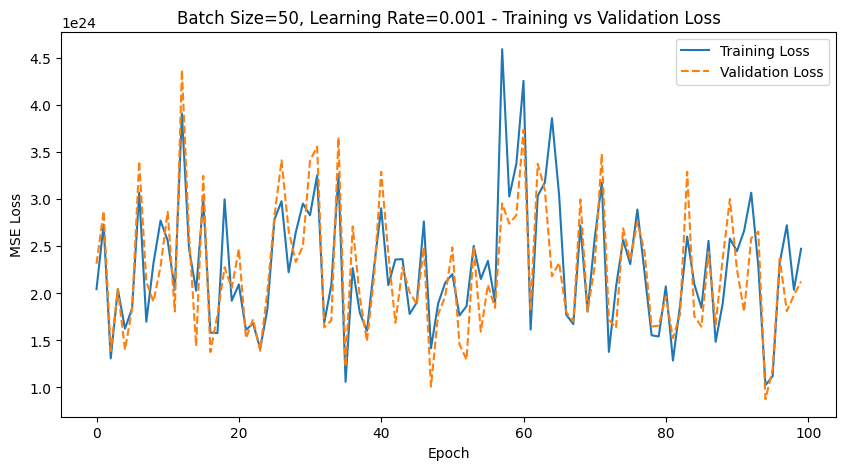

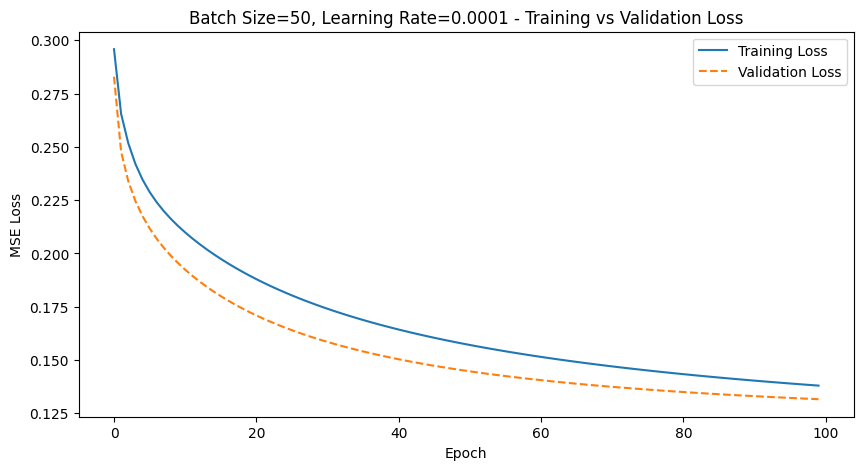

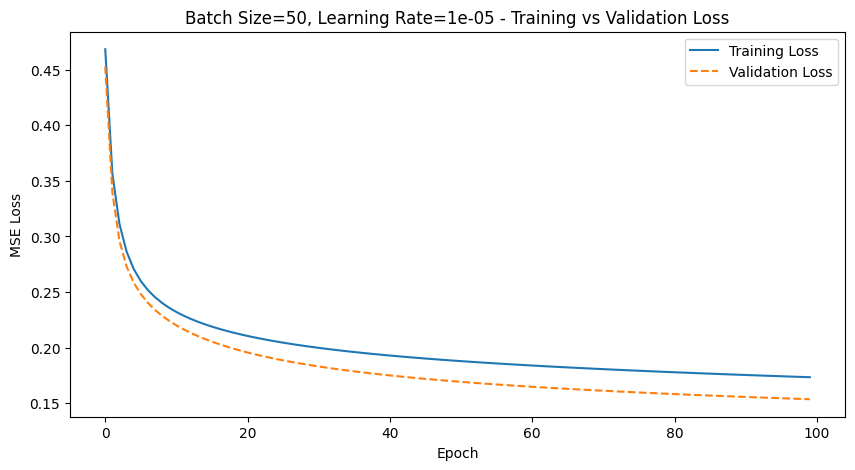

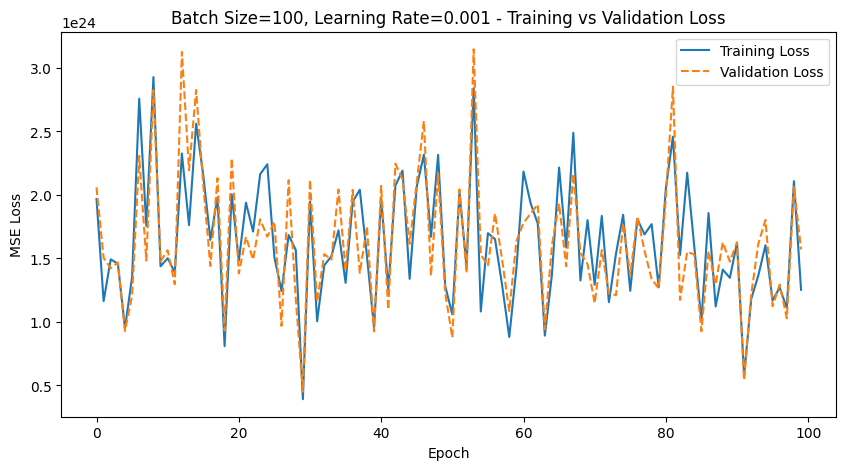

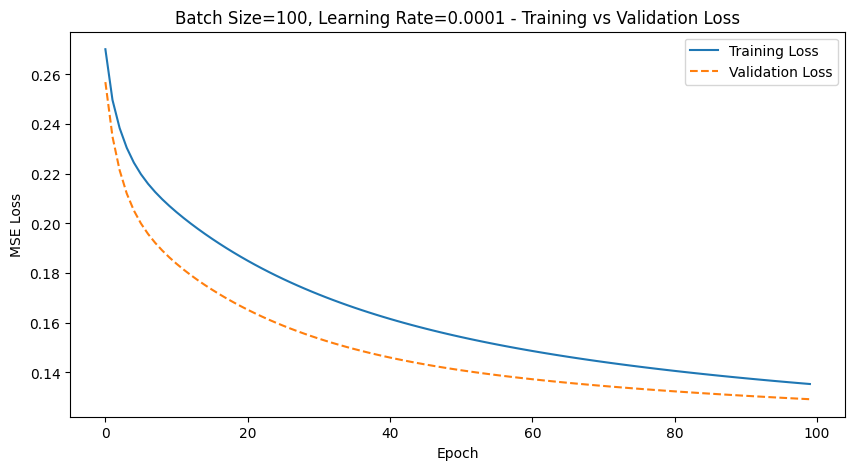

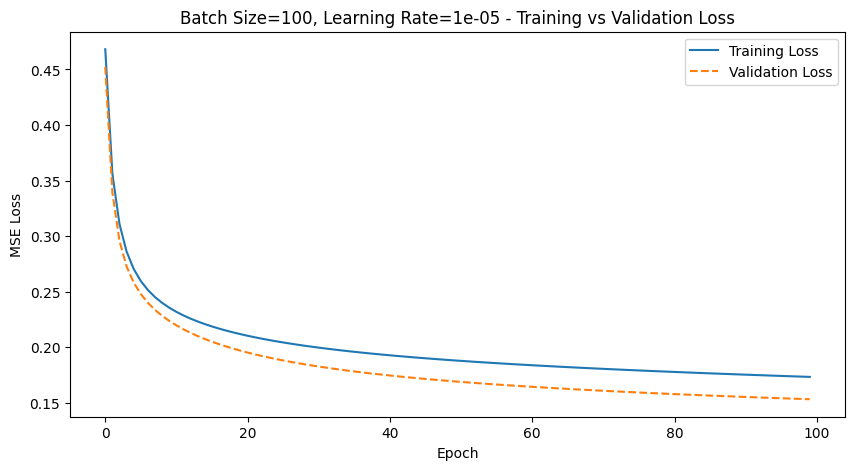

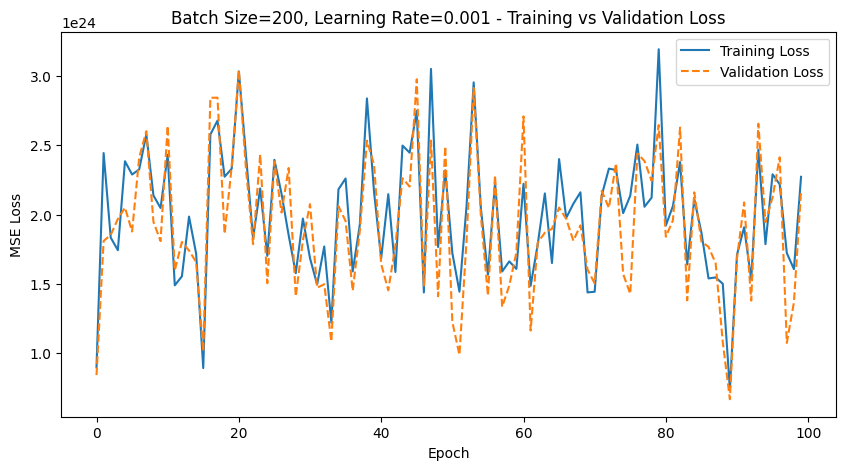

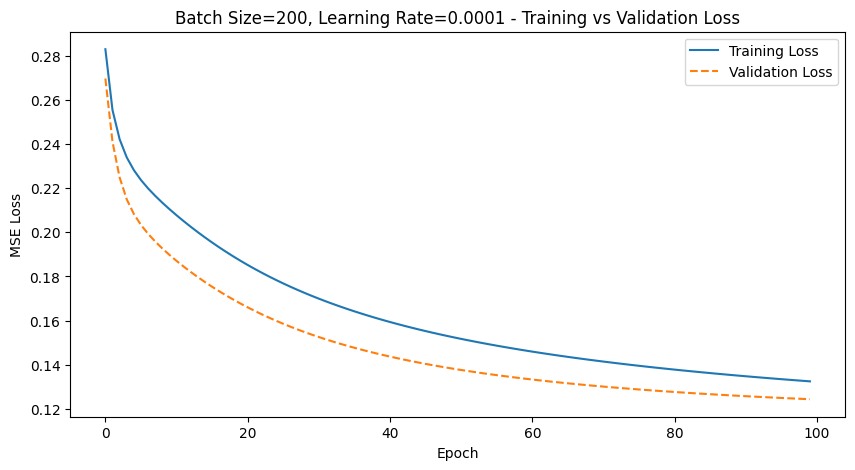

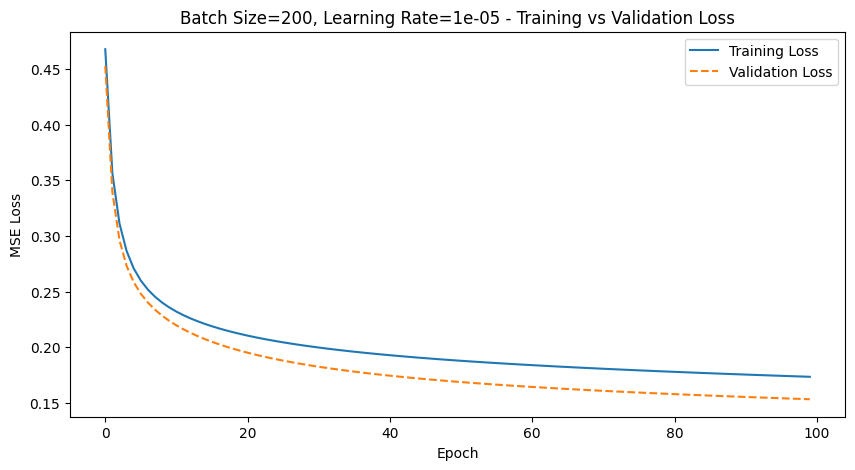


Final Results (Impact of Batch Size and Learning Rate on MSE):
Batch Size=50, Learning Rate=0.001 → Train MSE: 2474551154927403196743680.000000, Validation MSE: 2126568620926554714669056.000000
Batch Size=50, Learning Rate=0.0001 → Train MSE: 0.137949, Validation MSE: 0.131563
Batch Size=50, Learning Rate=1e-05 → Train MSE: 0.173448, Validation MSE: 0.153674
Batch Size=100, Learning Rate=0.001 → Train MSE: 1253117326436952614895616.000000, Validation MSE: 1571455242753009399103488.000000
Batch Size=100, Learning Rate=0.0001 → Train MSE: 0.135318, Validation MSE: 0.129193
Batch Size=100, Learning Rate=1e-05 → Train MSE: 0.173390, Validation MSE: 0.153296
Batch Size=200, Learning Rate=0.001 → Train MSE: 2272924853835128702500864.000000, Validation MSE: 2170484169920453495750656.000000
Batch Size=200, Learning Rate=0.0001 → Train MSE: 0.132381, Validation MSE: 0.124271
Batch Size=200, Learning Rate=1e-05 → Train MSE: 0.173440, Validation MSE: 0.153292


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Define Polynomial Degree
degree = 4  # Polynomial regression degree

# Define Hyperparameters to Compare
regs = ['l2', 'l1', 'elasticnet']  # Regularization types
lambdas = [0.01, 0.1, 1.0]  # Updated alpha values for regularization
learning_rates = [10**(-x) for x in range(3, 6)]  # Learning rates: 0.001, 0.0001, 0.00001
batch_sizes = [50, 100, 200]  # Batch sizes

# Transform features into polynomial
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)  # Expand features
X_test_poly = poly.transform(X_test)

# Standardize Features for SGD Stability
scaler_x = StandardScaler()
X_poly = scaler_x.fit_transform(X_poly)
X_test_poly = scaler_x.transform(X_test_poly)

# 4-Fold Cross-Validation
kf = KFold(n_splits=4, shuffle=True, random_state=2)

# Training and Evaluation
results_hyperparam = {}

for batch_size in batch_sizes:
    for lr in learning_rates:
        train_loss_curve, val_loss_curve = [], []

        for train_index, val_index in kf.split(X_poly):
            # Split Data
            X_train, X_val = X_poly[train_index], X_poly[val_index]
            y_train, y_val = y[train_index], y[val_index]

            # Standardize Target Variable
            scaler_y = StandardScaler()
            y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
            y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

            # Initialize Model with Given Learning Rate
            model = SGDRegressor(
                learning_rate='constant', eta0=lr, penalty='l2', max_iter=1,
                tol=None, random_state=42
            )

            # Training Loop
            n_epochs = 100
            train_losses, val_losses = [], []

            for epoch in range(n_epochs):
                for i in range(0, X_train.shape[0], batch_size):  # Mini-batch training
                    X_batch = X_train[i:i + batch_size]
                    y_batch = y_train_scaled[i:i + batch_size]
                    model.partial_fit(X_batch, y_batch)

                # Compute loss per epoch
                y_train_pred = model.predict(X_train)
                y_val_pred = model.predict(X_val)
                train_loss = mean_squared_error(y_train_scaled, y_train_pred)
                val_loss = mean_squared_error(y_val_scaled, y_val_pred)

                train_losses.append(train_loss)
                val_losses.append(val_loss)

            # Store loss curves (First fold only for visualization)
            if not train_loss_curve:
                train_loss_curve = train_losses
                val_loss_curve = val_losses

        # Store results
        results_hyperparam[(batch_size, lr)] = {
            "Train MSE": train_loss_curve[-1],
            "Validation MSE": val_loss_curve[-1]
        }

        # Plot Training vs Validation Loss
        plt.figure(figsize=(10, 5))
        plt.plot(train_loss_curve, label='Training Loss')
        plt.plot(val_loss_curve, linestyle='dashed', label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title(f'Batch Size={batch_size}, Learning Rate={lr} - Training vs Validation Loss')
        plt.legend()
        plt.show()

# Summary of Findings
print("\nFinal Results (Impact of Batch Size and Learning Rate on MSE):")
for (batch_size, lr), metrics in results_hyperparam.items():
    print(f"Batch Size={batch_size}, Learning Rate={lr} → Train MSE: {metrics['Train MSE']:.6f}, Validation MSE: {metrics['Validation MSE']:.6f}")

# **G. Part1 Prediction on Test Labels**
Make predictions of the labels on the test data, using the trained model with chosen hyperparameters. Summarize performance using the appropriate evaluation metric.\
1) Prediction on the Test Labels- 5 pts\
2) Reporting the Evaluation Metric-2 pts


In [ ]:
# Choose the best model from the previous steps (e.g., the polynomial model with SGD and the best hyperparameters)

best_model = SGDRegressor(random_state=42, max_iter=1000, learning_rate='constant', eta0=0.0001) #
poly = PolynomialFeatures(degree=2) #
X_train_poly = poly.fit_transform(Xtrain)
X_test_poly = poly.transform(Xtest)

best_model.fit(X_train_poly, ytrain)

# Make predictions on the test set
y_pred = best_model.predict(X_test_poly)

# Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(ytest, y_pred))
r2 = r2_score(ytest, y_pred)

print(f"Test RMSE: {rmse}")
print(f"Test R-squared: {r2}")


Test RMSE: 4.3629598628315165
Test R-squared: 0.673234144855241


# **G. Part2 Conclusions**

In this project, we trained different models (Normal equation, linear regression, and polynomial regression) on the dataset of happiness.

We splited the data into 80% training and 20% testing, along with 4-fold cross validation within training each of the model.

Here are key points of our project:

The model performance was evaluated using Root Mean Squared Error (RMSE) and R-squared.
The impact of polynomial degree, regularization (Ridge, Lasso, Elastic Net), batch size,
and learning rate on model performance were explored using cross-validation and training/validation loss analysis.
Polynomial regression with SGD showed the relationship between model complexity (polynomial degree)
and overfitting/underfitting. Three regularization techniques were applied to mitigate overfitting.
The effect of batch size and learning rate on the convergence and stability of the SGD algorithm was studied.
The best model (chosen from the experiments) was used to predict on a held-out test dataset.
Performance was summarized with the RMSE and R-squared metrics.

Future work:
1. More Robust Hyperparameter Tuning:
Implement a more systematic hyperparameter tuning process, such as grid search or random search, to find the optimal combination of hyperparameters (polynomial degree, regularization parameters, batch size, learning rate) to optimize the model performance. Consider using more sophisticated techniques, like Bayesian optimization.
2. Feature Engineering: Explore more advanced feature engineering techniques.  Creating new features or transforming existing features could significantly improve the predictive power of the models. Consider domain expertise to guide feature engineering.
3. Alternative Models: Investigate other regression algorithms, including tree-based models, support vector machines, or neural networks. Some of these models might be less sensitive to the scaling of the features or may naturally handle non-linear relationships more effectively. Also, this may help in solving negative R^2 error issue.
4. Data Preprocessing: More sophisticated imputation strategies or outlier detection and handling could be explored. Investigating the distributions of features and potentially applying transformations like log transformations or Box-Cox transformations could be valuable.
5. Error Analysis: Conduct a more in-depth error analysis to identify patterns in prediction errors.  Understanding the characteristics of the data points where the model performs poorly can provide valuable insights into model limitations and guide future improvements.
6. Regularization Parameter Tuning: Perform a more thorough search of the hyperparameter space for regularization strength (alpha). Consider using techniques like cross-validation to estimate the optimal value for alpha for different regularization methods.
7. Model Ensembling: Investigate combining different model predictions through techniques like bagging or boosting. Ensemble methods are known to increase prediction accuracy and robustness.